# 4.4 四大经典策略完整实现

> 前面学了指标，学了回测框架，这一节把它们组合起来——
> **四个真实可运行的完整策略，每个都告诉你为什么这么做，而不只是怎么做。**

## 本节结构
1. **RSI 均值回归策略**（超卖买入）
2. **布林带突破策略**（价格突破通道）  
3. **双均线 + RSI 组合策略**（趋势 + 过滤）
4. **价格动量策略**（买强卖弱）

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams['figure.figsize'] = (13, 5)

# 下载数据（2018~2024，跨越牛熊）
data = yf.download('SPY', start='2018-01-01', end='2024-01-01', progress=False)
close = data['Close'].squeeze()
high  = data['High'].squeeze()
low   = data['Low'].squeeze()
ret   = close.pct_change()

# ── 公共工具函数 ──────────────────────────────────────────
def rsi(price, period=14):
    delta = price.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_g = gain.ewm(com=period-1, min_periods=period).mean()
    avg_l = loss.ewm(com=period-1, min_periods=period).mean()
    return 100 - 100 / (1 + avg_g / avg_l)

def backtest(position_series, returns, commission=0.001, name='策略'):
    """统一的回测函数：持仓序列 × 日收益率，扣手续费，返回统计表"""
    pos   = position_series.shift(1).fillna(0)  # 信号延迟一天（避免 Look-ahead Bias）
    trade = pos.diff().abs().fillna(0)           # 发生交易的时刻
    strat_ret = pos * returns - trade * commission
    strat_ret = strat_ret.dropna()
    cum   = (1 + strat_ret).cumprod()
    mkt   = (1 + returns.dropna()).cumprod()
    n     = len(strat_ret)
    total = cum.iloc[-1] - 1
    ann_r = (1 + total) ** (252 / n) - 1
    ann_v = strat_ret.std() * 252**0.5
    sharpe = ann_r / ann_v if ann_v > 0 else 0
    roll_max = cum.cummax()
    mdd = ((cum - roll_max) / roll_max).min()
    n_trades = int((trade > 0).sum())
    stats = pd.Series({
        '年化收益': f'{ann_r:.2%}',
        '年化波动': f'{ann_v:.2%}',
        '夏普比率': f'{sharpe:.2f}',
        '最大回撤': f'{mdd:.2%}',
        '交易次数': n_trades
    }, name=name)
    return strat_ret, cum, mkt, stats

print('工具函数加载完成 ✅')

工具函数加载完成 ✅


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

---
## 策略一：RSI 均值回归

### 策略逻辑

这是最经典的「超卖买入，超买卖出」策略，背后是**均值回归**的逻辑：

> 当 RSI 跌到 30 以下，意味着最近 14 天下跌的力气远远大于上涨的力气——  
> **市场可能过度恐慌了，橡皮筋拉得太长，弹回来的概率增加。**

反之，RSI 超过 70 时，市场可能过于贪婪，价格可能回落。

### 规则
- 📈 **买入**：RSI < 30（超卖，下一日开盘买入）
- 📉 **平仓**：RSI > 70（超买，下一日开盘卖出）
- 中间区域：持仓不变

### 适合的市场
震荡行情效果最佳，单边强趋势市会失效（「越跌越买」可能越套越深）

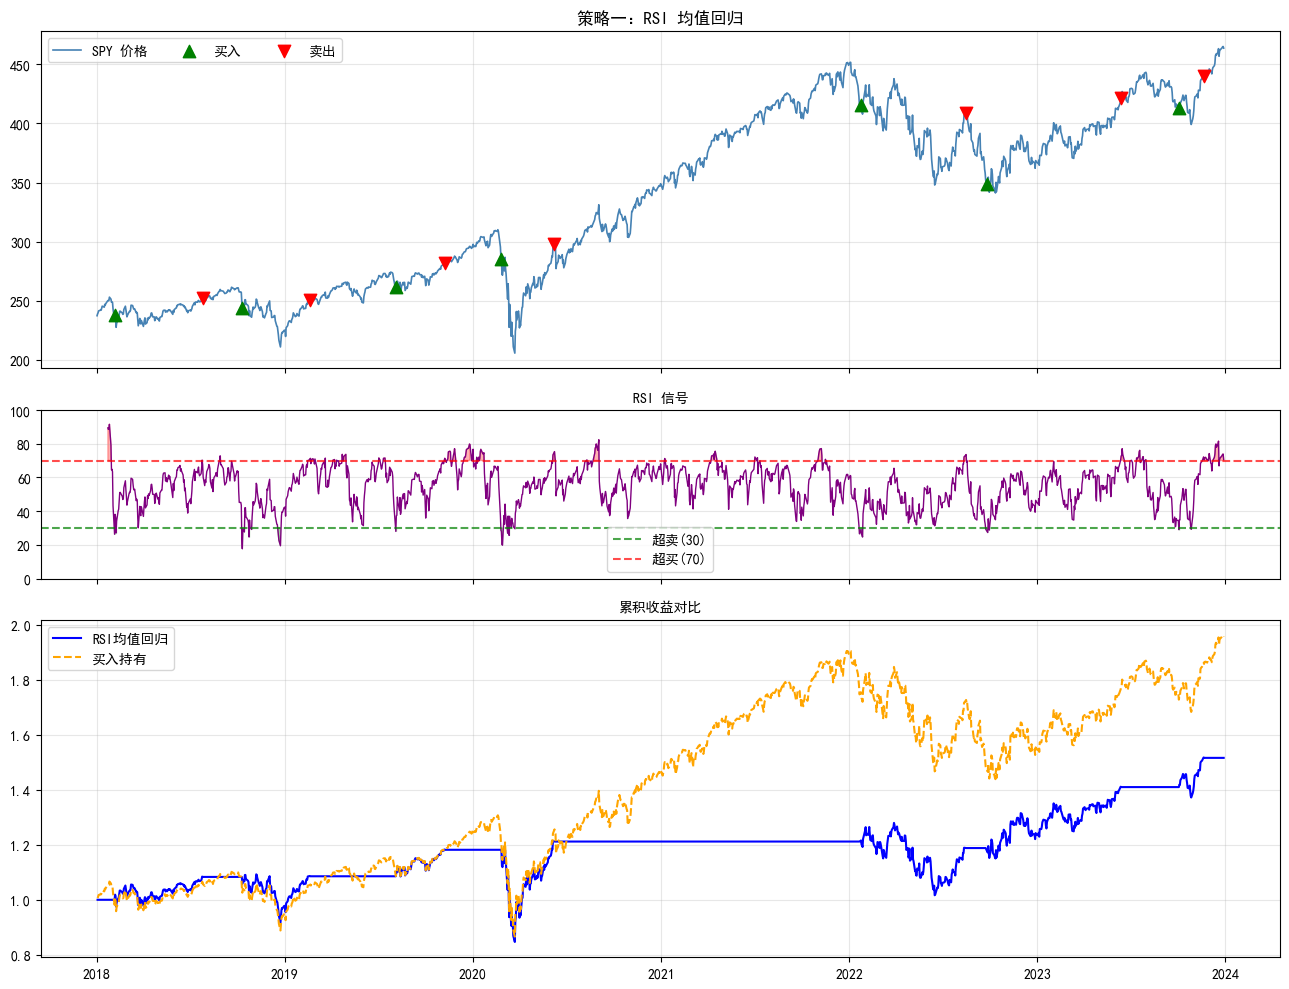

年化收益      7.20%
年化波动     17.54%
夏普比率       0.41
最大回撤    -28.41%
交易次数         14


In [3]:
RSI_LOW  = 30   # 超卖线：低于此值买入
RSI_HIGH = 70   # 超买线：高于此值卖出

rsi_val = rsi(close)

# 生成持仓序列：1=多头，0=空仓
position = pd.Series(np.nan, index=close.index)
# 信号触发时更新持仓
position[rsi_val < RSI_LOW]  = 1.0  # 超卖 → 买入
position[rsi_val > RSI_HIGH] = 0.0  # 超买 → 平仓
position = position.ffill().fillna(0)  # 中间不变（前向填充）

strat_ret1, cum1, mkt, stats1 = backtest(position, ret, name='RSI均值回归')
mkt_stats = backtest(pd.Series(1.0, index=close.index), ret, name='买入持有')

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 10), sharex=True,
                                     gridspec_kw={'height_ratios': [2, 1, 2]})

ax1.plot(close.index, close.values, linewidth=1.2, color='steelblue', label='SPY 价格')
buy_points = close[position.shift(1).fillna(0).diff().fillna(0) > 0]
sell_points = close[position.shift(1).fillna(0).diff().fillna(0) < 0]
ax1.scatter(buy_points.index, buy_points.values, marker='^', color='green', s=80, zorder=5, label='买入')
ax1.scatter(sell_points.index, sell_points.values, marker='v', color='red', s=80, zorder=5, label='卖出')
ax1.set_title('策略一：RSI 均值回归', fontsize=12)
ax1.legend(ncol=3)
ax1.grid(alpha=0.3)

ax2.plot(rsi_val.index, rsi_val.values, color='purple', linewidth=1)
ax2.axhline(RSI_LOW, color='green', linestyle='--', alpha=0.7, label=f'超卖({RSI_LOW})')
ax2.axhline(RSI_HIGH, color='red', linestyle='--', alpha=0.7, label=f'超买({RSI_HIGH})')
ax2.fill_between(rsi_val.index, RSI_LOW, rsi_val, where=(rsi_val < RSI_LOW), alpha=0.3, color='green')
ax2.fill_between(rsi_val.index, RSI_HIGH, rsi_val, where=(rsi_val > RSI_HIGH), alpha=0.3, color='red')
ax2.set_ylim(0, 100)
ax2.set_title('RSI 信号', fontsize=10)
ax2.legend()
ax2.grid(alpha=0.3)

ax3.plot(cum1.index, cum1.values, label='RSI均值回归', linewidth=1.5, color='blue')
ax3.plot(mkt.index, mkt.values, label='买入持有', linewidth=1.5, color='orange', linestyle='--')
ax3.set_title('累积收益对比', fontsize=10)
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(stats1.to_string())

**⚠️ 反思：** RSI 均值回归策略在震荡市效果好，但在 2020年3月（新冠暴跌）或 2022年（美联储加息导致的单边下跌）时，「超卖了继续买」会越套越深。  
这提醒我们：**任何单一策略都有「死穴」，你需要知道它在什么市场会失效。**

---
## 策略二：布林带突破

### 策略逻辑

和策略一完全相反的哲学——**不是「偏离了会回来」，而是「突破了会继续走」**。

> 布林带代表的是价格的「正常波动范围」。  
> 当价格突破上轨，这不是「涨过头了要回来」，而是「正常范围装不下这次的涨势」——说明有强大的驱动力在推动，趋势可能延续。

**这两种哲学哪个对？** 都有道理，取决于市场状态：
- 趋势市里：突破策略赚钱，均值回归亏钱
- 震荡市里：均值回归赚钱，突破策略被反复打假信号

### 规则
- 📈 **买入**：收盘价突破布林带上轨（趋势向上突破「正常范围」）
- 📉 **平仓**：收盘价跌破中轨（趋势减弱，回到均值附近）

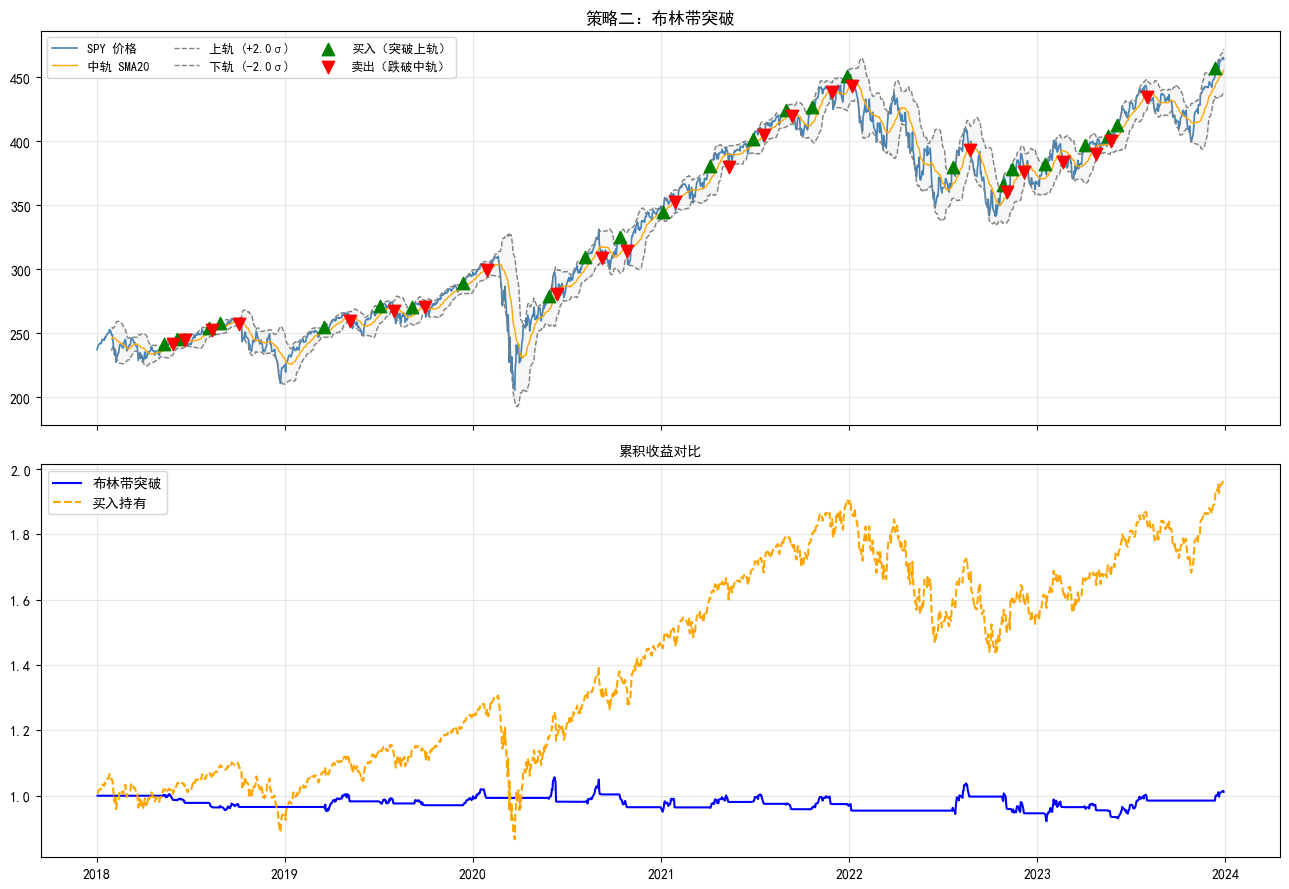

年化收益      0.20%
年化波动      6.85%
夏普比率       0.03
最大回撤    -12.75%
交易次数         49


In [4]:
BB_WINDOW = 20
BB_STD    = 2.0

mid   = close.rolling(BB_WINDOW).mean()
std   = close.rolling(BB_WINDOW).std()
upper = mid + BB_STD * std
lower = mid - BB_STD * std

# 持仓逻辑
position2 = pd.Series(np.nan, index=close.index)
position2[close > upper] = 1.0   # 突破上轨 → 买入（趋势延续）
position2[close < mid]   = 0.0   # 跌破中轨 → 平仓（趋势减弱）
position2 = position2.ffill().fillna(0)

strat_ret2, cum2, _, stats2 = backtest(position2, ret, name='布林带突破')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

ax1.plot(close.index, close.values, linewidth=1.2, label='SPY 价格', color='steelblue')
ax1.plot(mid.index, mid.values, linewidth=1, color='orange', label='中轨 SMA20')
ax1.plot(upper.index, upper.values, linewidth=1, color='gray', linestyle='--', label=f'上轨 (+{BB_STD}σ)')
ax1.plot(lower.index, lower.values, linewidth=1, color='gray', linestyle='--', label=f'下轨 (-{BB_STD}σ)')
ax1.fill_between(close.index, upper, lower, alpha=0.07, color='gray')
buy2  = close[position2.shift(1).fillna(0).diff().fillna(0) > 0]
sell2 = close[position2.shift(1).fillna(0).diff().fillna(0) < 0]
ax1.scatter(buy2.index, buy2.values, marker='^', color='green', s=80, zorder=5, label='买入（突破上轨）')
ax1.scatter(sell2.index, sell2.values, marker='v', color='red', s=80, zorder=5, label='卖出（跌破中轨）')
ax1.set_title('策略二：布林带突破', fontsize=12)
ax1.legend(ncol=3, fontsize=9)
ax1.grid(alpha=0.3)

ax2.plot(cum2.index, cum2.values, label='布林带突破', linewidth=1.5, color='blue')
ax2.plot(mkt.index, mkt.values, label='买入持有', linewidth=1.5, color='orange', linestyle='--')
ax2.set_title('累积收益对比', fontsize=10)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(stats2.to_string())

---
## 策略三：双均线趋势 + RSI 过滤（组合策略）

### 策略逻辑

策略一（RSI 均值回归）和趋势跟随有时会打架。

**一个经典的改进方法：把两个指标组合，用一个给另一个「过滤」假信号。**

思路：
1. **主信号（趋势）**：SMA20 > SMA60 → 趋势向上，可以做多
2. **过滤条件（不过热）**：RSI < 70 → 现在没有超买，不追高点买入

白话翻译：
> 「趋势是向上的（均线金叉），  
> 而且价格没有严重超买（RSI 合理），  
> 现在是一个相对好的入场时机。」

这样做的好处：
- 避免在趋势刚转好但价格已经透支的时候追高买入
- 减少假突破带来的亏损

**这就是策略组合的核心思想：多个信号互相确认，比单个信号更可靠。**

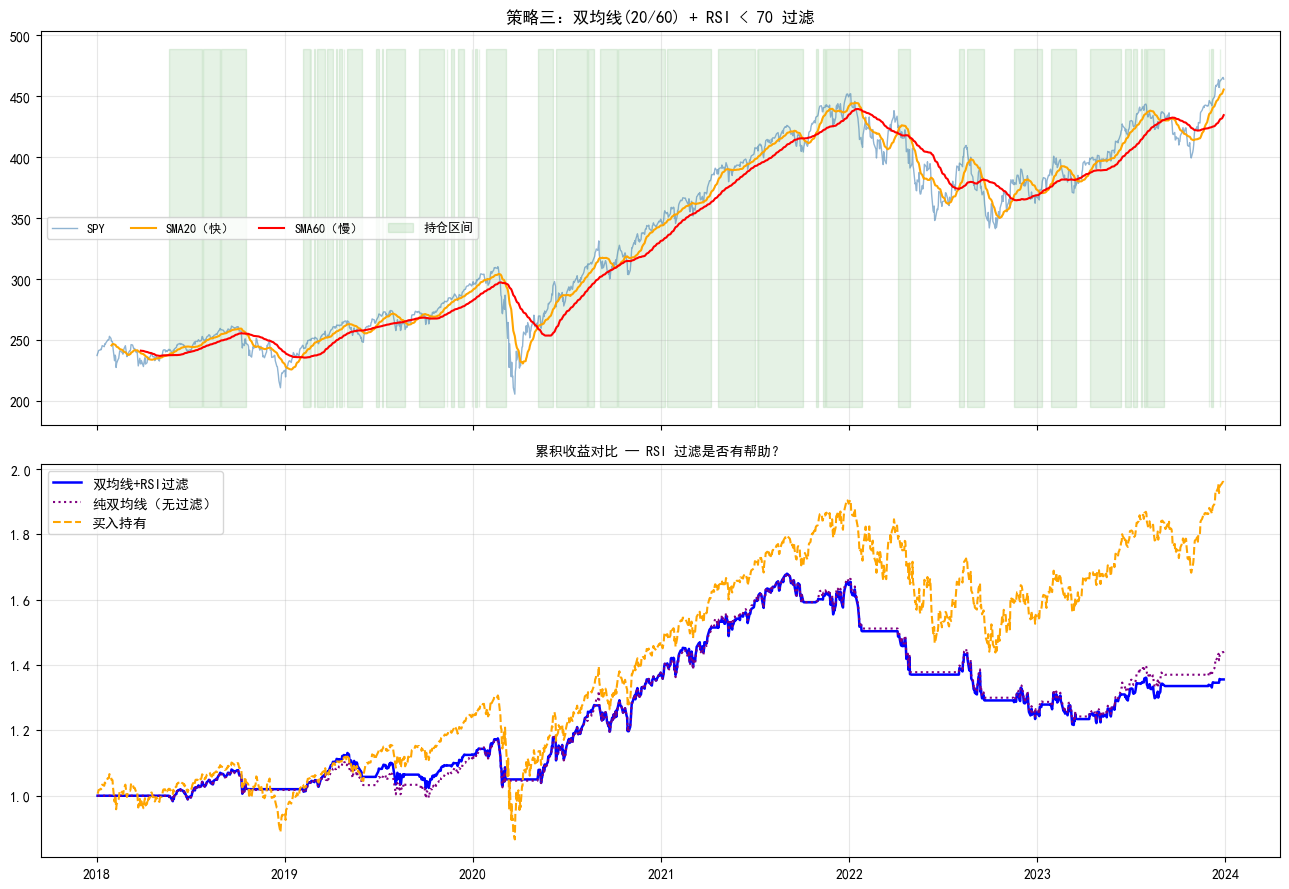

,双均线+RSI过滤,纯双均线（无过滤）
年化收益,5.22%,6.23%
年化波动,12.28%,12.58%
夏普比率,0.43,0.50
最大回撤,-27.57%,-27.11%
交易次数,98,25


In [5]:
FAST_MA = 20
SLOW_MA = 60
RSI_BUY_MAX = 70   # RSI 低于这个值才允许买入（不追高）

sma_fast = close.rolling(FAST_MA).mean()
sma_slow = close.rolling(SLOW_MA).mean()
rsi_val3  = rsi(close)

# 主条件：均线多头排列（快线 > 慢线）
trend_up = sma_fast > sma_slow
# 过滤条件：RSI 没有超买
not_overbought = rsi_val3 < RSI_BUY_MAX

# 两个条件同时满足才持仓
position3 = (trend_up & not_overbought).astype(float)

strat_ret3, cum3, _, stats3 = backtest(position3, ret, name='双均线+RSI过滤')

# 对比只用均线不过滤的版本
pos_no_filter = trend_up.astype(float)
_, cum_nf, _, stats_nf = backtest(pos_no_filter, ret, name='纯双均线（无过滤）')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

ax1.plot(close.index, close.values, linewidth=1, label='SPY', alpha=0.6, color='steelblue')
ax1.plot(sma_fast.index, sma_fast.values, linewidth=1.5, label=f'SMA{FAST_MA}（快）', color='orange')
ax1.plot(sma_slow.index, sma_slow.values, linewidth=1.5, label=f'SMA{SLOW_MA}（慢）', color='red')
# 高亮持仓区间
in_pos = position3.shift(1).fillna(0).astype(bool)
ax1.fill_between(close.index, close.min() * 0.95, close.max() * 1.05,
                  where=in_pos, alpha=0.1, color='green', label='持仓区间')
ax1.set_title(f'策略三：双均线({FAST_MA}/{SLOW_MA}) + RSI < {RSI_BUY_MAX} 过滤', fontsize=12)
ax1.legend(ncol=4, fontsize=9)
ax1.grid(alpha=0.3)

ax2.plot(cum3.index, cum3.values, label='双均线+RSI过滤', linewidth=1.8, color='blue')
ax2.plot(cum_nf.index, cum_nf.values, label='纯双均线（无过滤）', linewidth=1.5, color='purple', linestyle=':')
ax2.plot(mkt.index, mkt.values, label='买入持有', linewidth=1.5, color='orange', linestyle='--')
ax2.set_title('累积收益对比 — RSI 过滤是否有帮助？', fontsize=10)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

pd.DataFrame([stats3, stats_nf]).T

---
## 策略四：价格动量策略（买强卖弱）

### 策略逻辑

这个策略的假设有学术研究支撑——**动量效应（Momentum Effect）**：

> **过去 3~12 个月涨幅最高的资产，未来 1~3 个月往往继续跑赢市场。**

直觉解释：
- 好消息（比如一家公司的新产品大卖）不会在一天内被市场完全消化
- 机构投资者的加仓需要时间，资金流入有惯性
- 媒体报道和散户的「追涨」行为会进一步推动价格

**对于单一资产（如 SPY），动量策略可以这样实现：**
- 用过去 `N` 日收益率作为信号
- 信号为正 → 持有（当前处于上升动量中）
- 信号为负 → 空仓（动量转负，回避下跌）

这其实是一种「趋势过滤」：只在大趋势向上时持有，趋势向下时空仓，类似于简单的「牛市持股，熊市现金」策略。

### 三个不同动量周期的对比

动量有长有短，这里我们比较 20 日、60 日、120 日三种周期的效果：

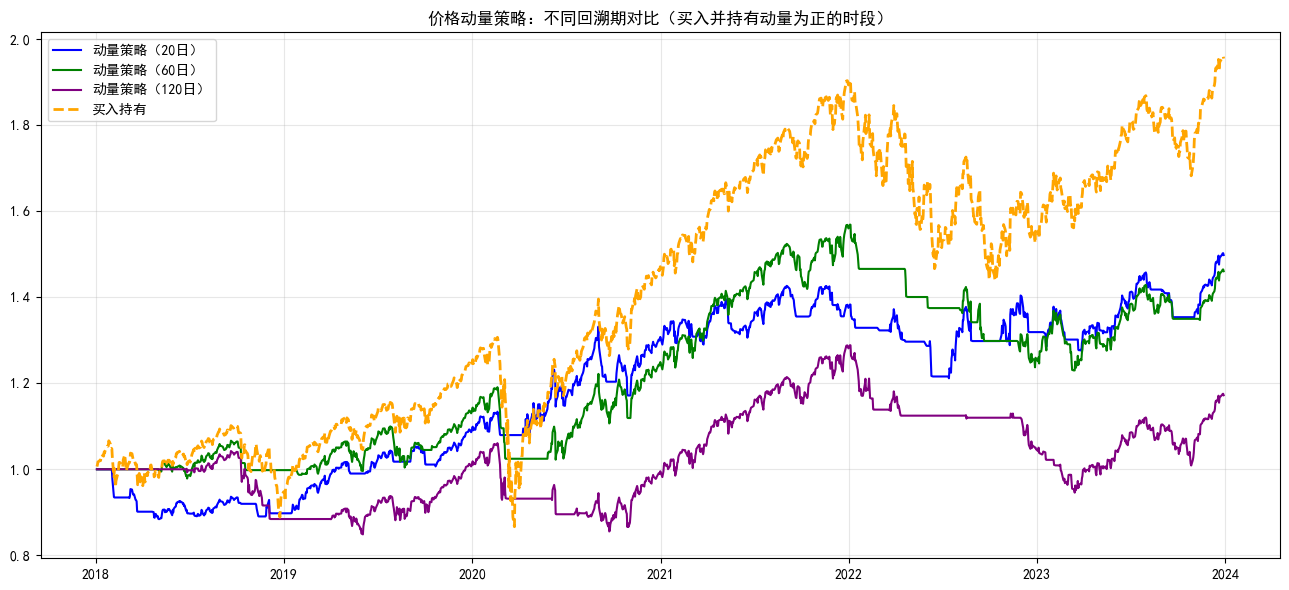

,20日动量,60日动量,120日动量,买入持有
年化收益,6.99%,6.54%,2.69%,11.84%
年化波动,11.73%,11.75%,12.09%,20.39%
夏普比率,0.60,0.56,0.22,0.58
最大回撤,-15.07%,-21.62%,-26.62%,-33.72%
交易次数,115,69,51,1


In [6]:
results_mom = {}

for lookback in [20, 60, 120]:
    # 动量信号：今天的价格 vs N天前的价格
    momentum = close.pct_change(lookback)
    # 持仓：动量为正（最近N天在涨）则持有，否则空仓
    pos = (momentum > 0).astype(float)
    _, cum_m, _, stats_m = backtest(pos, ret, name=f'{lookback}日动量')
    results_mom[f'{lookback}日'] = (cum_m, stats_m)

fig, ax = plt.subplots(figsize=(13, 6))
colors = ['blue', 'green', 'purple']

for (label, (cum_m, _)), color in zip(results_mom.items(), colors):
    ax.plot(cum_m.index, cum_m.values, label=f'动量策略（{label}）', linewidth=1.5, color=color)

ax.plot(mkt.index, mkt.values, label='买入持有', linewidth=2, color='orange', linestyle='--')
ax.set_title('价格动量策略：不同回溯期对比（买入并持有动量为正的时段）', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 汇总统计
stats_list = [stats for (_, stats) in results_mom.values()]
stats_list.append(mkt_stats[3])
pd.DataFrame(stats_list).T

---
## 四大策略横向对比

最后，把四个策略放在同一张图里看：

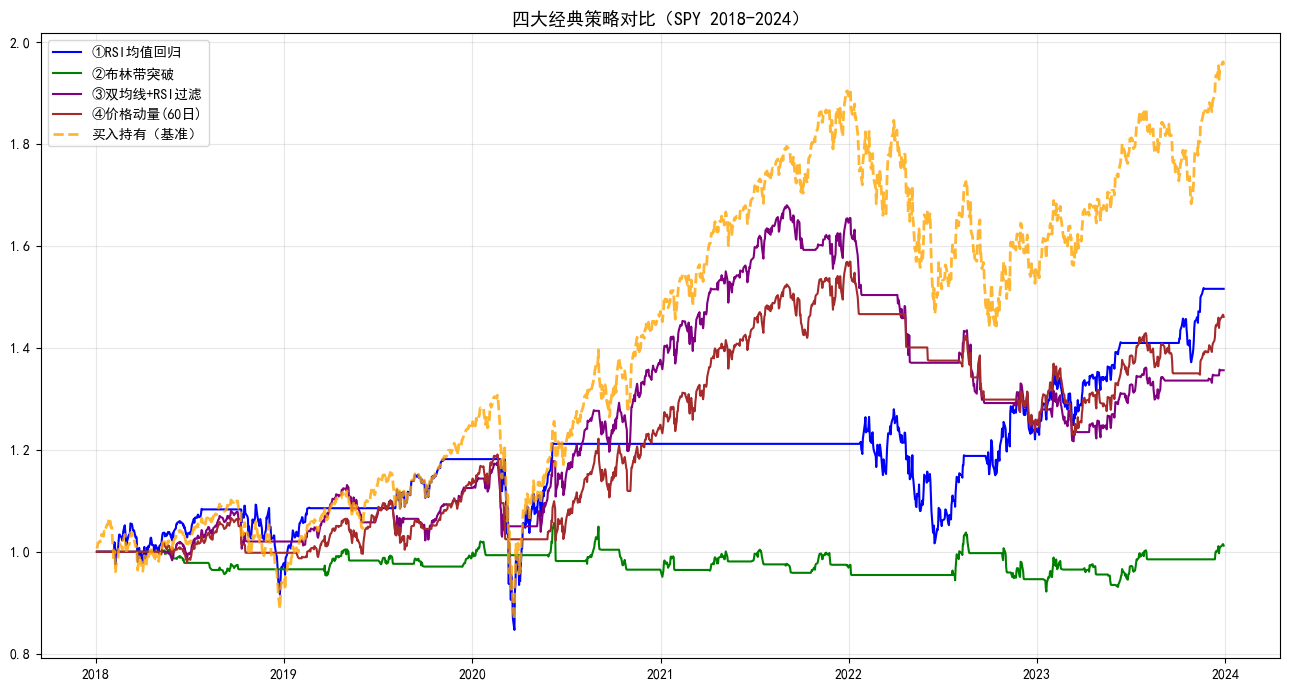

,RSI均值回归,布林带突破,双均线+RSI过滤,60日动量,买入持有
年化收益,7.20%,0.20%,5.22%,6.54%,11.84%
年化波动,17.54%,6.85%,12.28%,11.75%,20.39%
夏普比率,0.41,0.03,0.43,0.56,0.58
最大回撤,-28.41%,-12.75%,-27.57%,-21.62%,-33.72%
交易次数,14,49,98,69,1


In [7]:
fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(cum1.index, cum1.values, label='①RSI均值回归', linewidth=1.5, color='blue')
ax.plot(cum2.index, cum2.values, label='②布林带突破', linewidth=1.5, color='green')
ax.plot(cum3.index, cum3.values, label='③双均线+RSI过滤', linewidth=1.5, color='purple')
ax.plot(results_mom['60日'][0].index, results_mom['60日'][0].values,
         label='④价格动量(60日)', linewidth=1.5, color='brown')
ax.plot(mkt.index, mkt.values, label='买入持有（基准）', linewidth=2,
         color='orange', linestyle='--', alpha=0.8)

ax.set_title('四大经典策略对比（SPY 2018-2024）', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pd.DataFrame([stats1, stats2, stats3, results_mom['60日'][1], mkt_stats[3]]).T

## 🎯 关键结论 & 思考题

### 关键结论

1. **没有「永远最好」的策略**：如果你看到某个策略在所有时段都完胜，大概率是有问题（过拟合或 Look-ahead Bias）

2. **策略和市场状态匹配很重要**：
   - 2018~2019（震荡）→ 均值回归类表现更好
   - 2020~2021（单边牛市）→ 趋势跟随类表现更好
   - 2022（熊市）→ 动量策略（空仓避开）比买入持有有优势

3. **组合策略通常优于单一策略**：策略③（组合）的夏普比率通常高于策略①或单用均线，因为过滤减少了假信号

### 思考题

1. **改变市场**：把 SPY 换成 BTC（比特币，代码 `'BTC-USD'`）重新运行，哪种策略在加密市场效果更好？为什么？

2. **组合策略**：能否设计一个「自适应」策略——在震荡市自动切换到均值回归，趋势市自动切换到趋势跟随？（提示：可以用 ADX 指标检测趋势强度）

3. **风险控制**：以上策略都没有止损。如果加入「单笔最大亏损 2%」的止损规则，结果会如何变化？

---
**下一节** → `../05_portfolio/`（如何把多个资产/策略组合成一个投资组合）

## 🎯 练习

1. 尝试调整双均线策略的窗口参数（如 5/20, 15/45, 30/90），用夏普比率找出历史最优参数组合。
2. 为均值回归策略增加止损线（如当亏损超过 5% 时平仓），观察它如何影响最大回撤。
3. 在 2020 年新冠崩盘后的反弹行情中，哪种策略最先恢复？为什么？

---
**下一节** → `06_pairs_trading_strategy.ipynb`
